# Exercise 1 — LCG & tests for random numbers

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2, norm, kstwobign
from lcg import LinearCongruentialGenerator

np.random.seed(2026)
plt.rcParams["figure.figsize"] = (10, 4)
N = 10_000


def sample_lcg(n, seed, a, c, M):
    g = LinearCongruentialGenerator(seed=seed, a=a, c=c, M=M)
    return np.array([g.next_uniform() for _ in range(n)])

## Tests

In [ ]:
def histogram_counts(u, k=10, lo=0.0, hi=1.0):
    edges = np.linspace(lo, hi, k + 1)
    counts = np.zeros(k, dtype=int)
    w = (hi - lo) / k
    for x in u:
        idx = min(int((x - lo) / w), k - 1)
        if 0 <= idx < k:
            counts[idx] += 1
    return counts, edges


def chi_square_test(u, k=10):
    counts, _ = histogram_counts(u, k)
    e = len(u) / k
    T = np.sum((counts - e) ** 2 / e)
    return dict(stat=T, df=k - 1, p=chi2.sf(T, k - 1))


def ks_test(u): # case 1: U(0,1), all params known
    n = len(u); x = np.sort(u); i = np.arange(1, n + 1)
    Dn = max(np.max(i / n - x), np.max(x - (i - 1) / n))
    adj = (np.sqrt(n) + 0.12 + 0.11 / np.sqrt(n)) * Dn
    return dict(Dn=Dn, adjusted=adj, crit95=1.358, p=kstwobign.sf(np.sqrt(n) * Dn))


def runs_test_median(u): # Wald-Wolfowitz
    med = np.median(u); s = u[u != med] > med
    n1, n2 = int(s.sum()), int((~s).sum())
    R = 1 + int(np.sum(s[1:] != s[:-1]))
    mu = 2 * n1 * n2 / (n1 + n2) + 1
    var = 2 * n1 * n2 * (2 * n1 * n2 - n1 - n2) / ((n1 + n2) ** 2 * (n1 + n2 - 1))
    Z = (R - mu) / np.sqrt(var)
    return dict(stat=Z, p=2 * norm.sf(abs(Z)))


def updown_runs_test(u):
    n = len(u); up = np.diff(u) > 0
    X = 1 + int(np.sum(up[1:] != up[:-1]))
    Z = (X - (2 * n - 1) / 3) / np.sqrt((16 * n - 29) / 90)
    return dict(stat=Z, p=2 * norm.sf(abs(Z)))


def correlation_test(u, h):
    n = len(u); Ch = np.mean(u[:n - h] * u[h:])
    Z = (Ch - 0.25) / np.sqrt(7 / (144 * n))
    return dict(Ch=Ch, stat=Z, p=2 * norm.sf(abs(Z)))


def evaluate(u, name, alpha=0.05):
    print(f"== {name} (n={len(u)}) ==")
    cs = chi_square_test(u); print(f"chi2  T={cs['stat']:.2f} df={cs['df']} p={cs['p']:.3f}")
    ks = ks_test(u); print(f"KS    adj={ks['adjusted']:.3f} (95% crit 1.358) p={ks['p']:.3f}")
    print(f"runs(median) Z={runs_test_median(u)['stat']:.2f} p={runs_test_median(u)['p']:.3f}")
    print(f"up/down runs Z={updown_runs_test(u)['stat']:.2f} p={updown_runs_test(u)['p']:.3f}")
    for h in (1, 2, 3, 5, 10):
        co = correlation_test(u, h)
        print(f"corr h={h:<2d} Ch={co['Ch']:.4f} Z={co['stat']:.2f} p={co['p']:.3f}")
    print()

## Part 1 — LCG: bad parameter choice

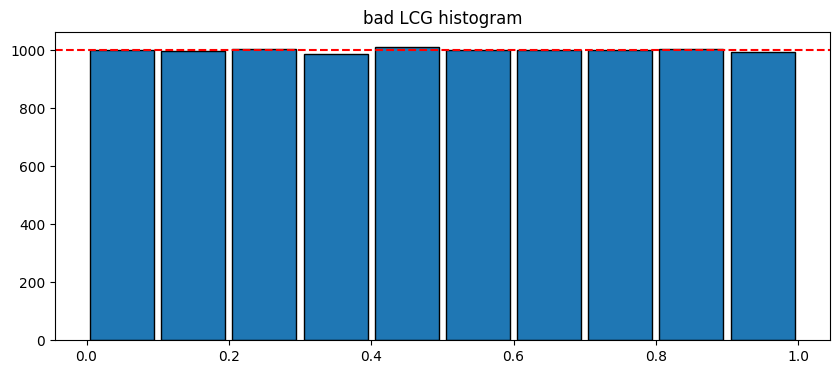

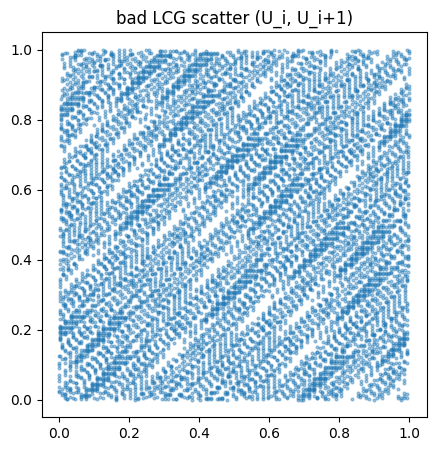

== bad LCG (a=129, c=1, M=2^16) (n=10000) ==
chi2  T=0.34 df=9 p=1.000
KS    adj=0.151 (95% crit 1.358) p=1.000
runs(median) Z=0.20 p=0.841
up/down runs Z=-4.23 p=0.000
corr h=1  Ch=0.2507 Z=0.30 p=0.767
corr h=2  Ch=0.2501 Z=0.05 p=0.958
corr h=3  Ch=0.2461 Z=-1.78 p=0.075
corr h=5  Ch=0.2529 Z=1.31 p=0.191
corr h=10 Ch=0.2508 Z=0.38 p=0.701



In [3]:
U_bad = sample_lcg(N, seed=1, a=129, c=1, M=2**16)

# 1(a) histogram, 10 classes
counts, edges = histogram_counts(U_bad, 10)
plt.bar((edges[:-1] + edges[1:]) / 2, counts, width=0.09, edgecolor="black")
plt.axhline(N / 10, color="red", ls="--"); plt.title("bad LCG histogram"); plt.show()

# 1(b) scatter
plt.figure(figsize=(5, 5)); plt.scatter(U_bad[:-1], U_bad[1:], s=4, alpha=0.4)
plt.gca().set_aspect("equal"); plt.title("bad LCG scatter (U_i, U_i+1)"); plt.show()

evaluate(U_bad, "bad LCG (a=129, c=1, M=2^16)")

## Part 1(c) — final (good) choice: ANSI C LCG

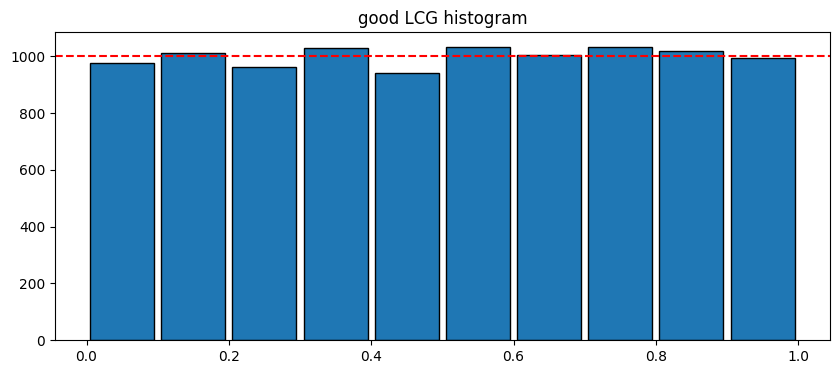

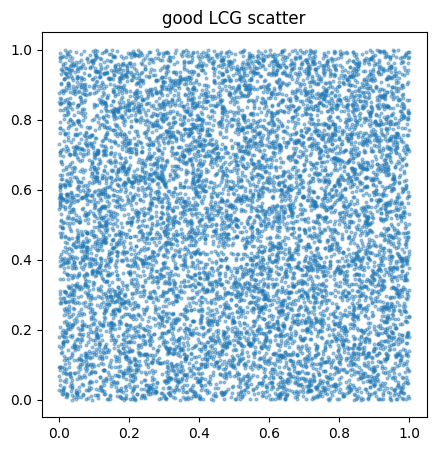

== good LCG (a=1103515245, c=12345, M=2^31) (n=10000) ==
chi2  T=8.88 df=9 p=0.448
KS    adj=0.912 (95% crit 1.358) p=0.378
runs(median) Z=0.20 p=0.841
up/down runs Z=0.21 p=0.837
corr h=1  Ch=0.2524 Z=1.09 p=0.274
corr h=2  Ch=0.2539 Z=1.79 p=0.074
corr h=3  Ch=0.2522 Z=1.00 p=0.318
corr h=5  Ch=0.2521 Z=0.96 p=0.335
corr h=10 Ch=0.2525 Z=1.12 p=0.264



In [4]:
U_good = sample_lcg(N, seed=1, a=1103515245, c=12345, M=2**31)

counts, edges = histogram_counts(U_good, 10)
plt.bar((edges[:-1] + edges[1:]) / 2, counts, width=0.09, edgecolor="black")
plt.axhline(N / 10, color="red", ls="--"); plt.title("good LCG histogram"); plt.show()

plt.figure(figsize=(5, 5)); plt.scatter(U_good[:-1], U_good[1:], s=4, alpha=0.4)
plt.gca().set_aspect("equal"); plt.title("good LCG scatter"); plt.show()

evaluate(U_good, "good LCG (a=1103515245, c=12345, M=2^31)")

## Part 2 — system generators

In [5]:
U_pcg = np.random.default_rng(2026).random(N)
U_mt = np.random.RandomState(2026).random_sample(N)
evaluate(U_pcg, "NumPy PCG64")
evaluate(U_mt, "Mersenne Twister")

== NumPy PCG64 (n=10000) ==
chi2  T=13.91 df=9 p=0.125
KS    adj=0.971 (95% crit 1.358) p=0.304
runs(median) Z=0.24 p=0.810
up/down runs Z=0.89 p=0.372
corr h=1  Ch=0.2556 Z=2.52 p=0.012
corr h=2  Ch=0.2565 Z=2.96 p=0.003
corr h=3  Ch=0.2570 Z=3.16 p=0.002
corr h=5  Ch=0.2554 Z=2.46 p=0.014
corr h=10 Ch=0.2538 Z=1.72 p=0.086

== Mersenne Twister (n=10000) ==
chi2  T=4.69 df=9 p=0.861
KS    adj=0.810 (95% crit 1.358) p=0.530
runs(median) Z=0.36 p=0.719
up/down runs Z=-0.06 p=0.956
corr h=1  Ch=0.2508 Z=0.36 p=0.717
corr h=2  Ch=0.2509 Z=0.42 p=0.672
corr h=3  Ch=0.2493 Z=-0.31 p=0.755
corr h=5  Ch=0.2512 Z=0.54 p=0.592
corr h=10 Ch=0.2507 Z=0.34 p=0.737



## Part 3 — sufficiency of one sample

One sample gives one p-value per test (itself ~U(0,1) under H0), so a single result is not
conclusive. Action: repeat over many seeds and inspect the distribution of p-values.

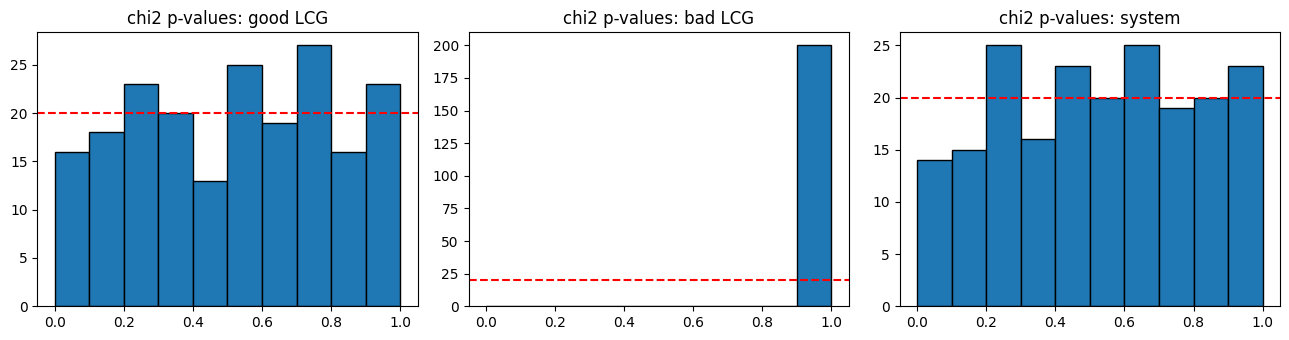

good LCG   KS of p-values p=0.500  frac p<0.05 = 0.04
bad LCG    KS of p-values p=0.000  frac p<0.05 = 0.00
system     KS of p-values p=0.494  frac p<0.05 = 0.06


In [6]:
def collect_p(make, n_rep=200):
    return np.array([chi_square_test(make(r))["p"] for r in range(n_rep)])

p_good = collect_p(lambda r: sample_lcg(N, r + 1, 1103515245, 12345, 2**31))
p_bad = collect_p(lambda r: sample_lcg(N, r + 1, 129, 1, 2**16))
p_sys = collect_p(lambda r: np.random.default_rng(r + 1).random(N))

fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
for a_, p_, t_ in zip(ax, [p_good, p_bad, p_sys], ["good LCG", "bad LCG", "system"]):
    a_.hist(p_, bins=10, range=(0, 1), edgecolor="black")
    a_.axhline(len(p_) / 10, color="red", ls="--"); a_.set_title(f"chi2 p-values: {t_}")
plt.tight_layout(); plt.show()

for p_, t_ in zip([p_good, p_bad, p_sys], ["good LCG", "bad LCG", "system"]):
    print(f"{t_:10s} KS of p-values p={ks_test(p_)['p']:.3f}  frac p<0.05 = {np.mean(p_ < 0.05):.2f}")